# MBTI Personality Classification using Fine-tuned BERT and SMOTE

This notebook presents an end-to-end Machine Learning pipeline to predict an individual's Myers-Briggs Type Indicator (MBTI) personality type based on social media posts.

### Key Technical Features:
1. **State-of-the-Art Model**: Fine-tuned `bert-base-uncased` sequence classifier from Hugging Face.
2. **Advanced Data Augmentation (SMOTE)**: Solves massive class imbalance (almost 50x ratio) by generating synthetic minority examples from TF-IDF vectors, perfectly balancing the dataset across 16 personality categories.
3. **Rigorous Data Leakage Prevention**: Automatically strips all MBTI personality keywords from the training text, ensuring the model learns the styling, lexical, and syntactic features rather than direct clues.
4. **Persistent Multi-Account Save System**: Configured to save checkpoints directly to Google Drive periodically. If your Colab GPU quota expires, you can effortlessly resume training on another account starting exactly from your last saved epoch checkpoint!

In [1]:
# Install Hugging Face Datasets and Evaluation libraries
!pip install datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.0 MB/s eta 0:00:00


## 1. Imports and Environment Setup

In [2]:
import os
import re
import json
import numpy as np
import pandas as pd
import torch
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from collections import Counter
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    Trainer, TrainingArguments
)
from datasets import Dataset
from evaluate import load
from google.colab import drive

# Mount Google Drive for persistent storage
drive.mount('/content/drive')

# Set up hardware acceleration (using Colab T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using computational device: {device}")

# Initialize Lemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

Mounted at /content/drive
Using computational device: cuda


[nltk_data] Downloading package wordnet to /root/nltk_data...


## 2. Preprocessing & Post Extraction

We clean the raw text by stripping links, non-alphabetic signs, and any occurrence of the MBTI class names themselves. Then, we combine smaller posts into rich, coherent text chunks up to `max_length = 256` to create uniform training samples.

In [3]:
def preprocess_text(df):
    # Remove links and represent post splits with special tokens
    df["posts"] = df["posts"].apply(lambda x: re.sub(r'https?:\/\/.*?[\s+]', '', x.replace("|||", " EOSTokenPost ").replace("|", " ") + " "))

    # Retain English letters only
    df["posts"] = df["posts"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x + " "))

    # Convert to lowercase
    df["posts"] = df["posts"].apply(lambda x: x.lower())

    # Remove letter repetitions (e.g. "sooooo" -> "")
    df["posts"] = df["posts"].apply(lambda x: re.sub(r'([a-z])\1{2,}[\s|\w]*', '', x + " "))

    # Filter out extremely short (0-3 chars) or overly long (30-1000 chars) tokens
    df["posts"] = df["posts"].apply(lambda x: re.sub(r'(\b\w{0,3})?\b', '', x))
    df["posts"] = df["posts"].apply(lambda x: re.sub(r'(\b\w{30,1000})?\b', '', x))

    # Strip direct MBTI mentions to prevent model data leakage
    pers_types = ['INFP' ,'INFJ', 'INTP', 'INTJ', 'ENTP', 'ENFP', 'ISTP' ,'ISFP' ,'ENTJ', 'ISTJ','ENFJ', 'ISFJ' ,'ESTP', 'ESFP' ,'ESFJ' ,'ESTJ']
    pers_types = [p.lower() for p in pers_types]
    pattern = re.compile("(" + "|".join(pers_types) + ")")
    df["posts"] = df["posts"].apply(lambda x: re.sub(pattern, '', x))

    return df

def extract_and_combine(row, posts_list, max_len, min_length=3, max_length=256):
    current_post = ""
    personality_type = row[0]
    posts_content = row[1]

    for post in posts_content.split("eostokenpost"):
        post = post.strip()
        # Lemmatize and clean
        post = " ".join([lemmatizer.lemmatize(word) for word in post.split() if len(word) > 3])
        post_len = len(post)

        if post_len < min_length:
            continue

        if len(current_post) + post_len >= max_length:
            posts_list.append((personality_type, current_post.strip()))
            max_len[0] = max(max_len[0], len(current_post.strip()))
            current_post = post
        else:
            current_post += " " + post if current_post else post

    if current_post.strip():
        posts_list.append((personality_type, current_post.strip()))
        max_len[0] = max(max_len[0], len(current_post.strip()))

## 3. Dataset Loading and Initial Preprocessing

In [4]:
# Path to Kaggle MBTI dataset in Drive
dataset_path = '/content/drive/MyDrive/MBTI/mbti_1.csv'
data = pd.read_csv(dataset_path)

print("Original dataset sample:")
print(data.head())

# Run text cleanup
data = preprocess_text(data)

# Segment and group texts
posts = []
max_len = [0]
# Using standard iterator loop to prevent deprecation warnings and performance issues
for row in data.itertuples(index=False):
    extract_and_combine(row, posts, max_len)

print("Maximum text chunk length:", max_len[0])

# Convert back to DataFrame
data = pd.DataFrame(posts, columns=['type', 'posts'])

# Set up target labels mapping
label_mapping = {label: idx for idx, label in enumerate(data['type'].unique())}
data['type_id'] = data['type'].map(label_mapping)

print("Mapped personality ID sample:")
print(data.head(5))

Original dataset sample:
   type                                              posts
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1  ENTP  'I'm finding the lack of me in these posts ver...
2  INTP  'Good one  _____   https://www.youtube.com/wat...
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...
4  ENTJ  'You're fired.|||That's another silly misconce...
Maximum text chunk length: 256
Mapped personality ID sample:
   type                                              posts  type_id
0  INFJ  moment sportscenter play prank what been most ...        0
1  INFJ  hello sorry hear your distress only natural re...        0
2  INFJ  prozac wellbrutin least thirty minute moving y...        0
3  INFJ  basically come with three item youve determine...        0
4  INFJ  thing moderation sims indeed video game good t...        0


## 4. Class Balancing using SMOTE (Data Augmentation)

MBTI datasets are inherently imbalanced because online MBTI forums are heavily populated by certain types (like INFPs, INFJs, INTPs) compared to other types (like ESTJs, ESFJs).

To prevent the BERT model from becoming heavily biased, we vectorize our cleaned posts using TF-IDF and apply SMOTE to synthesize minority samples, reaching a perfectly balanced dataset.

Class distribution before balancing: Counter({6: 32233, 0: 27222, 2: 25409, 3: 21141, 1: 11261, 7: 9768, 9: 5874, 8: 4236, 4: 4176, 11: 3850, 5: 2798, 10: 2675, 12: 1330, 15: 828, 14: 719, 13: 641})
Class distribution after SMOTE balancing: Counter({0: 32233, 1: 32233, 2: 32233, 3: 32233, 4: 32233, 5: 32233, 6: 32233, 7: 32233, 8: 32233, 9: 32233, 10: 32233, 11: 32233, 12: 32233, 13: 32233, 14: 32233, 15: 32233})
Balanced dataset size: 515728 samples


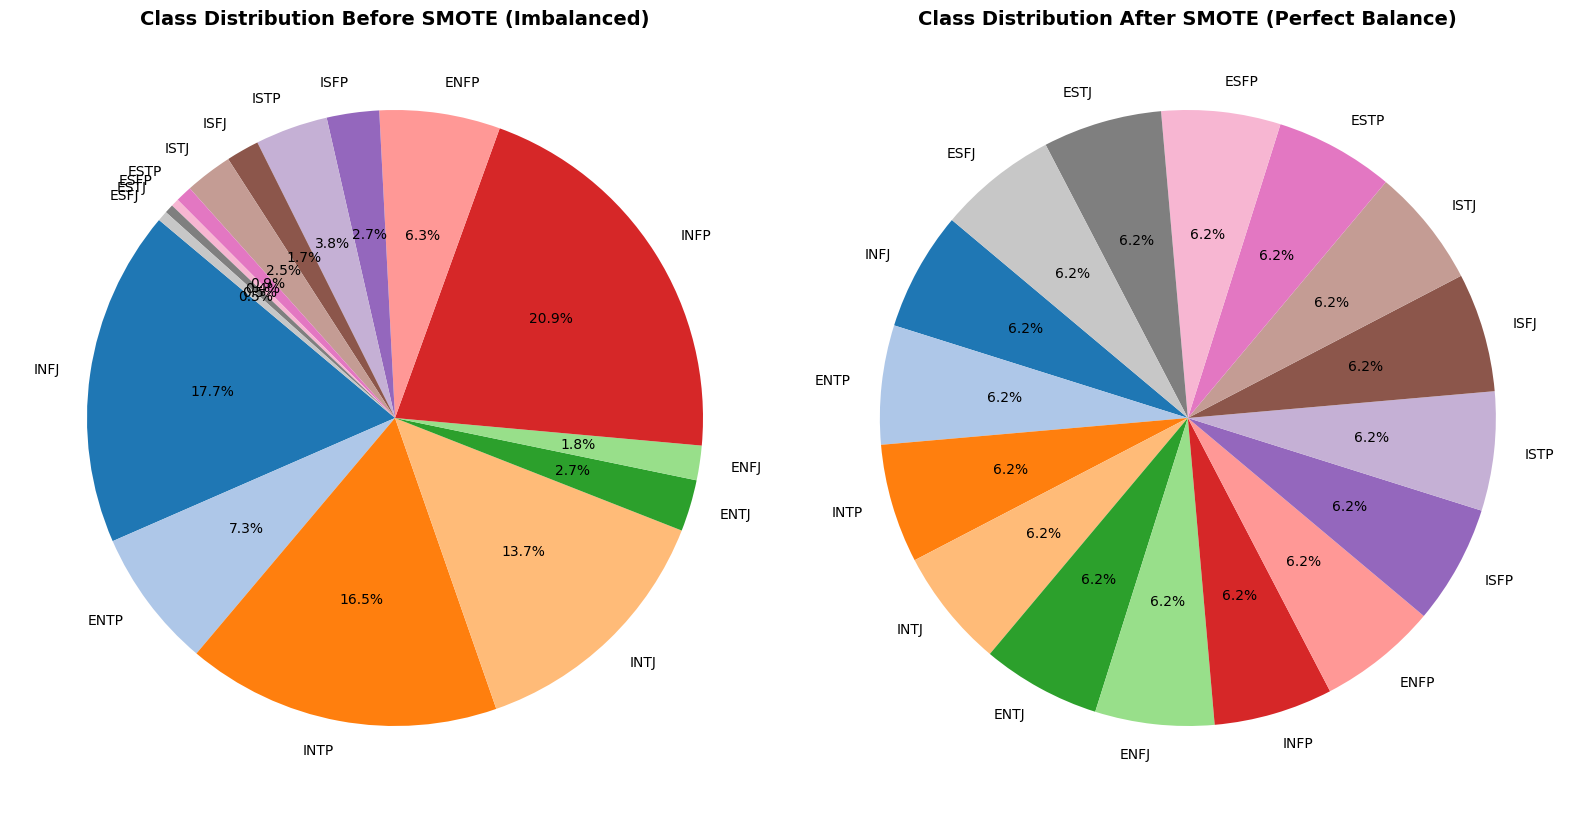

In [5]:
# Fit TF-IDF Vectorizer on cleaned texts
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
posts_tfidf = vectorizer.fit_transform(data['posts'])
type_ids = data['type_id']

inverse_label_mapping = {v: k for k, v in label_mapping.items()}
print("Class distribution before balancing:", Counter(type_ids))

# Apply SMOTE data augmentation
smote = SMOTE(sampling_strategy='auto', random_state=42)
x_posts, y_type_id = smote.fit_resample(posts_tfidf, type_ids)

z_type = [inverse_label_mapping[y] for y in y_type_id]
print("Class distribution after SMOTE balancing:", Counter(y_type_id))

# Reconstruct dense string sentences from balanced vectors for BERT compatibility
reconstructed_posts = vectorizer.inverse_transform(x_posts)
reconstructed_posts = [' '.join(tokens) for tokens in reconstructed_posts]

data_balanced = pd.DataFrame({
    'posts': reconstructed_posts,
    'type_id': y_type_id,
    'type': z_type
})

print(f"Balanced dataset size: {len(data_balanced)} samples")

# Visualizing class distribution before and after SMOTE
import matplotlib.pyplot as plt
before_counts = Counter(type_ids)
after_counts = Counter(y_type_id)

# Get labels and sizes
before_labels = [inverse_label_mapping[k] for k in before_counts.keys()]
before_sizes = list(before_counts.values())

after_labels = [inverse_label_mapping[k] for k in after_counts.keys()]
after_sizes = list(after_counts.values())

# Plot side-by-side pie charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
colors = plt.cm.tab20.colors

ax1.pie(before_sizes, labels=before_labels, autopct='%1.1f%%', startangle=140, colors=colors)
ax1.set_title('Class Distribution Before SMOTE (Imbalanced)', fontsize=14, fontweight='bold')

ax2.pie(after_sizes, labels=after_labels, autopct='%1.1f%%', startangle=140, colors=colors)
ax2.set_title('Class Distribution After SMOTE (Perfect Balance)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Fine-tuning the BERT Model

We tokenize the balanced dataset using the standard pre-trained BERT tokenizer and train it using the Hugging Face `Trainer` API.

> [!IMPORTANT]
> To prevent losing progress due to Google Colab GPU limits, **checkpoints are saved directly to Google Drive** (`/content/drive/MyDrive/MBTI/results/`) after each epoch. We set a limit of keeping only the last 2 checkpoints (`save_total_limit=2`) to prevent filling up Google Drive space (each checkpoint with optimizer state is ~1.3 GB).

In [ ]:
# Train/Validation Split (80/20) maintaining stratification
train_df, val_df = train_test_split(
    data_balanced,
    test_size=0.2,
    random_state=42,
    stratify=data_balanced['type']
)

# Initialize Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    tokenized = tokenizer(examples['posts'], padding="max_length", truncation=True, max_length=256)
    tokenized["labels"] = examples["type_id"]
    return tokenized

# Build Datasets
train_data = Dataset.from_pandas(train_df[['posts', 'type_id']])
val_data = Dataset.from_pandas(val_df[['posts', 'type_id']])

# Tokenize Splits in Parallel
train_data = train_data.map(tokenize_function, batched=True, num_proc=4)
val_data = val_data.map(tokenize_function, batched=True, num_proc=4)

# Load Pretrained BERT Sequence Classifier
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_mapping))
model.to(device)

# Setup Metrics Calculation
accuracy_metric = load("accuracy")

def compute_metrics(pred):
    logits, labels = pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

# Hyperparameter Settings (Saving directly to persistent Google Drive)
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/MBTI/results", # Checkpoints saved straight to Drive
    eval_strategy="epoch",
    save_strategy="epoch", # Save checkpoints at the end of every training epoch
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="/content/drive/MyDrive/MBTI/logs", # Logs saved to Drive
    save_total_limit=2, # Keeps only the last 2 checkpoints to avoid filling Drive space
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=True  # Mixed precision GPU acceleration
)

# Setup Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# ----------------------------------------------------------------------------------------
# RESUME TRAINING METHOD:
# If your GPU session disconnected or ran out of quota, simply mount the same Google Drive
# on your other account and uncomment/run the line below to resume training from the last epoch!
#
# trainer.train(resume_from_checkpoint=True)
# ----------------------------------------------------------------------------------------

# Normal training initiation (starts from scratch if folder is empty, or resumes if specified):
trainer.train()

## 6. Saving the Model persistently

To make sure our training work is not lost when our Google Colab session expires, we save the final best model, tokenizers, and class mapping settings persistently into our mounted Google Drive folder.

In [ ]:
model_save_path = "/content/drive/MyDrive/MBTI/saved_model"

print(f"Saving trained model and config to {model_save_path}...")
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save mapping structure as a JSON config file
with open(os.path.join(model_save_path, "label_mapping.json"), "w") as f:
    json.dump(label_mapping, f)

print("Model saved successfully! Ready for decoupled production deployment.")

## 7. Model Evaluation & Performance Metrics

To showcase the model's accuracy and performance on your resume, we run a fast validation evaluation. By reconstructing the exact train/test split (using the identical split random state), we can score the model on validation data, print a full classification report (Precision, Recall, F1-Score), and plot a Confusion Matrix without needing to retrain the model.

Loading fine-tuned model and tokenizer for evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tokenizing validation split...


Map:   0%|          | 0/103146 [00:00<?, ? examples/s]

Running validation classification prediction...



=== Classification Report ===
              precision    recall  f1-score   support

        INFJ       0.13      0.34      0.19      6447
        ENTP       0.40      0.37      0.38      6447
        INTP       0.25      0.27      0.26      6446
        INTJ       0.19      0.35      0.25      6447
        ENTJ       0.74      0.62      0.67      6447
        ENFJ       0.72      0.68      0.70      6446
        INFP       0.33      0.60      0.43      6447
        ENFP       0.38      0.39      0.38      6446
        ISFP       0.82      0.52      0.64      6446
        ISTP       0.72      0.44      0.55      6447
        ISFJ       0.84      0.53      0.65      6447
        ISTJ       0.86      0.43      0.57      6446
        ESTP       0.96      0.61      0.75      6447
        ESFP       0.97      0.64      0.77      6446
        ESTJ       0.98      0.67      0.79      6447
        ESFJ       0.93      0.65      0.76      6447

    accuracy                           0.51    10

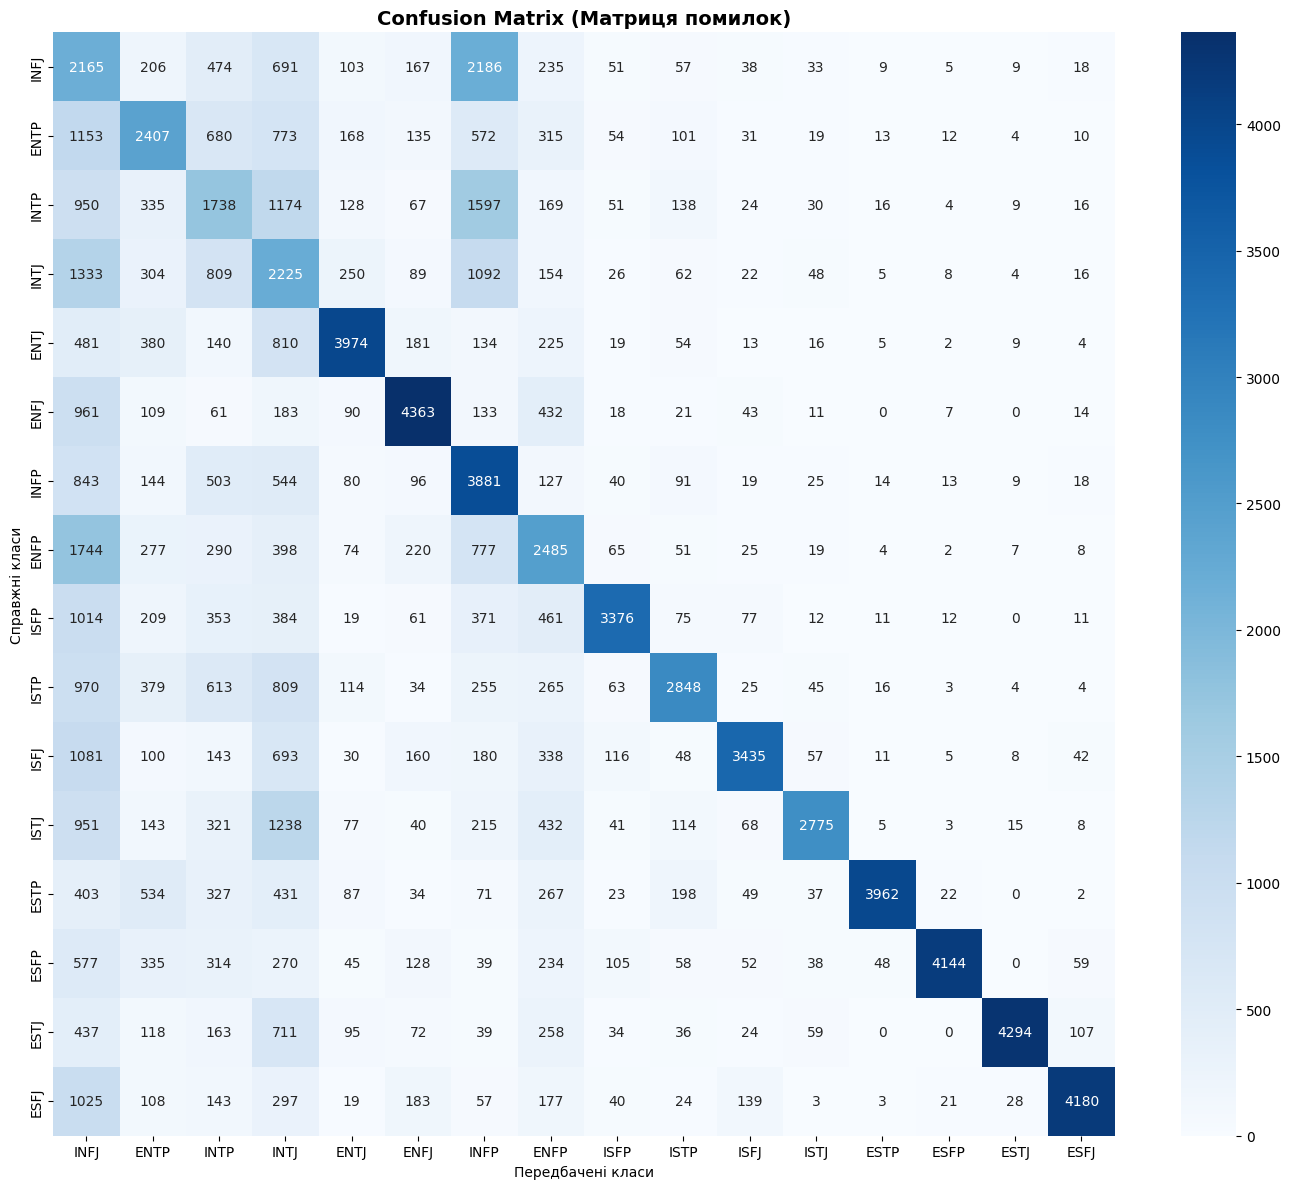

In [6]:
# Model Evaluation & Confusion Matrix Visualisation
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import Trainer, TrainingArguments, BertTokenizer, BertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from datasets import Dataset

model_path = "/content/drive/MyDrive/MBTI_model"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not os.path.exists(model_path):
    print(f"Помилка: модель за шляхом {model_path} не знайдена. Спочатку перевірте шляхи.")
else:
    # Load mapping
    with open(os.path.join(model_path, "label_mapping.json"), "r") as f:
        loaded_mapping = json.load(f)
    reverse_mapping = {int(val): key for key, val in loaded_mapping.items()}

    print("Loading fine-tuned model and tokenizer for evaluation...")
    eval_tokenizer = BertTokenizer.from_pretrained(model_path)
    eval_model = BertForSequenceClassification.from_pretrained(model_path).to(device)

    # Split validation data (identical to training random split)
    train_df, val_df = train_test_split(
        data_balanced,
        test_size=0.2,
        random_state=42,
        stratify=data_balanced['type']
    )

    def tokenize_eval_function(examples):
        tokenized = eval_tokenizer(examples['posts'], padding="max_length", truncation=True, max_length=256)
        tokenized["labels"] = examples["type_id"]
        return tokenized

    print("Tokenizing validation split...")
    val_data = Dataset.from_pandas(val_df[['posts', 'type_id']])
    val_data = val_data.map(tokenize_eval_function, batched=True)

    # Setup simple trainer for evaluation
    eval_args = TrainingArguments(
        output_dir="./eval_temp",
        per_device_eval_batch_size=64,
        report_to="none"
    )

    trainer = Trainer(
        model=eval_model,
        args=eval_args,
        processing_class=eval_tokenizer
    )

    print("Running validation classification prediction...")
    predictions = trainer.predict(val_data)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    # Generate textual performance report
    target_names = [reverse_mapping[i] for i in range(16)]
    print("\n=== Classification Report ===")
    print(classification_report(labels, preds, target_names=target_names))

    # Plot and display the Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
    plt.title('Confusion Matrix (Матриця помилок)', fontsize=14, fontweight='bold')
    plt.xlabel('Передбачені класи')
    plt.ylabel('Справжні класи')
    plt.savefig(os.path.join(model_path, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


## 8. Decoupled Fast Inference

Here, we resolve the variable issues at the bottom of the notebook by importing all dependencies, loading the model persistently from Google Drive, and executing clean real-time predictions.

In [7]:
# === ОДНОРАЗОВИЙ ЗАПУСК: СТВОРЕННЯ LABEL_MAPPING.JSON ===
import os
import json
import pandas as pd

dataset_path = '/content/drive/MyDrive/MBTI/mbti_1.csv'
model_path = '/content/drive/MyDrive/MBTI_model'

if os.path.exists(dataset_path):
    print(f"Завантаження датасету з: {dataset_path}...")
    df = pd.read_csv(dataset_path, usecols=['type'])
    unique_types = df['type'].unique()
    label_mapping = {label: idx for idx, label in enumerate(unique_types)}

    os.makedirs(model_path, exist_ok=True)
    output_file = os.path.join(model_path, 'label_mapping.json')
    with open(output_file, 'w') as f:
        json.dump(label_mapping, f)
    print(f"Файл {output_file} успішно створено!")
else:
    print(f"Помилка: датасет не знайдено за шляхом {dataset_path}")


Завантаження датасету з: /content/drive/MyDrive/MBTI/mbti_1.csv...
Файл /content/drive/MyDrive/MBTI_model/label_mapping.json успішно створено!


In [12]:
import torch
import json
import os
import re
from transformers import BertTokenizer, BertForSequenceClassification

model_path = "/content/drive/MyDrive/MBTI_model"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not os.path.exists(model_path):
    print("Saved model directory not found! Run the saving cell or check Google Drive paths.")
else:
    # Load settings & classes map
    with open(os.path.join(model_path, "label_mapping.json"), "r") as f:
        loaded_mapping = json.load(f)
    reverse_mapping = {int(val): key for key, val in loaded_mapping.items()}

    # Load pretrained components
    print("Loading fine-tuned model and tokenizers...")
    inference_tokenizer = BertTokenizer.from_pretrained(model_path)
    inference_model = BertForSequenceClassification.from_pretrained(model_path).to(device)

    def predict_social_type(text):
        text = text.lower()
        text = re.sub(r'https?://[^\s<>"]+|www\.[^\s<>"]+', ' ', text)
        text = re.sub(r'[^0-9a-z]', ' ', text)

        inputs = inference_tokenizer(
            text, padding="max_length", truncation=True,
            max_length=256, return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = inference_model(**inputs)

        prediction = torch.argmax(outputs.logits, dim=-1).item()
        predicted_label = reverse_mapping[prediction]
        return predicted_label

    # Interactive testing loop
    print("\nReady for prediction. Enter custom text (Type 'exit' to stop):")
    while True:
        user_input = input("Enter text to analyze: ")
        if user_input.strip().lower() == 'exit':
            print("Goodbye!")
            break
        if not user_input.strip():
            continue
        predicted_type = predict_social_type(user_input)
        print(f"Predicted MBTI Type: {predicted_type}\n")
    print("\nReady for prediction. Enter custom text (Type 'exit' to stop):")
    test_sentence = "I love brainstorming new project patterns and thinking about systemic workflows in complete quietness."
    print(f"Sample Input: \"{test_sentence}\"")
    print(f"Predicted Type: {predict_social_type(test_sentence)}\n")

Loading fine-tuned model and tokenizers...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Ready for prediction. Enter custom text (Type 'exit' to stop):
Enter text to analyze: My dream home is a sun-drenched, solar-powered villa overlooking the ocean. The design is completely sustainable, utilizing recycled materials, automated climate systems, and a green rooftop garden. With the sound of waves in the background, the open-plan interior is centered around an inspiring creative studio, offering the ultimate balance between high-tech innovation and natural calmness.
Predicted MBTI Type: INFJ

Enter text to analyze: Forget cozy villas and boring luxury. My dream space is a converted industrial warehouse turned into a high-tech fortress. It’s a raw, rebellious mix of exposed brick, neon graffiti, and cutting-edge tech, where the living room is a massive robotics lab and the garage is packed with custom hardware and 3D printers. Powered entirely by a rogue solar grid and guarded by advanced AI, this place doesn't follow any architectural rules. It’s loud, it’s autonomous, and i